# importing models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import classification_report, accuracy_score

# Loading the dataset from Hugging Face

In [2]:
df = load_dataset("HuyAugie/Smaller_AG_News_Dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


ag_news_train_balanced.parquet:   0%|          | 0.00/651k [00:00<?, ?B/s]

ag_news_train_imbalanced.parquet:   0%|          | 0.00/313k [00:00<?, ?B/s]

ag_news_test_small.parquet:   0%|          | 0.00/650k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5900 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4000 [00:00<?, ? examples/s]

# Training and Testing data

In [3]:
train_data = df["train"]
test_data = df["test"]

print(train_data)
print(test_data)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 5900
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 4000
})


# Convert into Dataframe

In [4]:
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

train_df.head()

,text,label,__index_level_0__
0,"Explosion Rocks Baghdad Neighborhood BAGHDAD, ...",0,8897.0
1,BBC reporters' log BBC correspondents record e...,0,88708.0
2,Israel welcomes Rice nomination; Palestinians ...,0,92698.0
3,Medical Journal Calls for a New Drug Watchdog ...,0,99489.0
4,Militants Kidnap Relatives of Iraqi Minister-T...,0,10525.0


# Displaying top 5 Rows

In [5]:
print(train_df.head())

                                                text  label  __index_level_0__
0  Explosion Rocks Baghdad Neighborhood BAGHDAD, ...      0             8897.0
1  BBC reporters' log BBC correspondents record e...      0            88708.0
2  Israel welcomes Rice nomination; Palestinians ...      0            92698.0
3  Medical Journal Calls for a New Drug Watchdog ...      0            99489.0
4  Militants Kidnap Relatives of Iraqi Minister-T...      0            10525.0


# Checking the Dataset Information

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5900 entries, 0 to 5899
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               5900 non-null   object 
 1   label              5900 non-null   int64  
 2   __index_level_0__  4000 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 138.4+ KB


# Check Missing Values

In [7]:
train_df.isnull().sum()

,0
text,0
label,0
__index_level_0__,1900


# Category Distribution

In [8]:
train_df["label"].value_counts()

,count
label,
0,2000
1,1300
2,1300
3,1300


# Prepare Text and Labels

In [9]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

# Tokenization

In [10]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding

In [11]:
max_len = 100

X_train_pad = pad_sequences(X_train_seq,
                            maxlen=max_len,
                            padding='post')

X_test_pad = pad_sequences(X_test_seq,
                           maxlen=max_len,
                           padding='post')

# Build Simple RNN Models

In [12]:
model = Sequential()

model.add(Embedding(input_dim=max_words,
                    output_dim=64,
                    input_length=max_len))

model.add(SimpleRNN(64))

model.add(Dense(32, activation='relu'))

model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Compile Model

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [15]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.2856 - loss: 1.3860 - val_accuracy: 0.5288 - val_loss: 1.3226
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.3801 - loss: 1.3074 - val_accuracy: 0.6000 - val_loss: 0.9939
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6110 - loss: 0.9617 - val_accuracy: 0.7492 - val_loss: 0.7033
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7528 - loss: 0.6709 - val_accuracy: 0.8636 - val_loss: 0.4357
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8650 - loss: 0.4219 - val_accuracy: 0.8898 - val_loss: 0.3753


# Evaluate Model

In [16]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4695 - loss: 1.4669
Test Loss : 1.466894507408142
Test Accuracy : 0.46950000524520874


# Predict

In [17]:
pred = model.predict(X_test_pad)

pred_labels = np.argmax(pred, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


# Accuracy

In [18]:
print("Accuracy:", accuracy_score(y_test, pred_labels))

Accuracy: 0.4695


# Classification Report

In [19]:
print(classification_report(y_test, pred_labels))

              precision    recall  f1-score   support

           0       0.54      0.46      0.50      1000
           1       0.47      0.46      0.46      1000
           2       0.43      0.51      0.47      1000
           3       0.45      0.45      0.45      1000

    accuracy                           0.47      4000
   macro avg       0.47      0.47      0.47      4000
weighted avg       0.47      0.47      0.47      4000



# Plot Accuracy

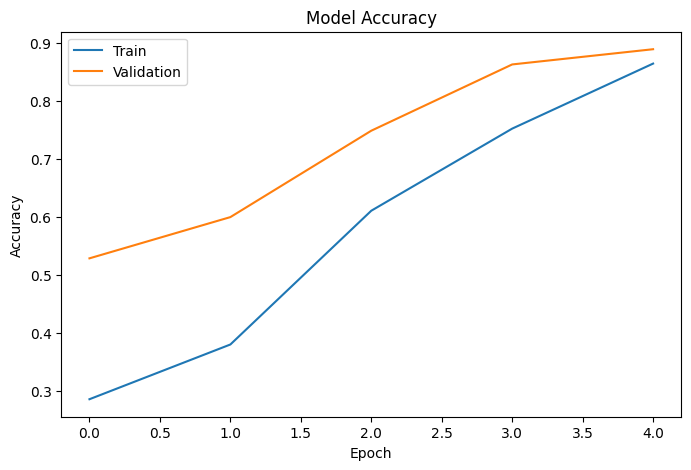

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

# Plot Loss

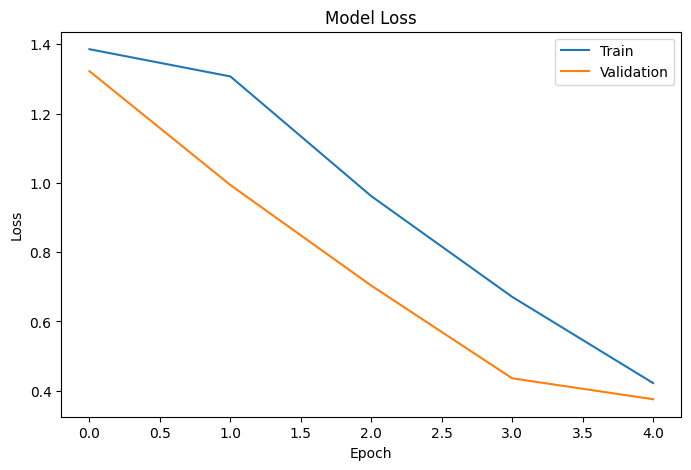

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# Test on a Custom News

In [22]:
news = ["Apple launches a new AI-powered iPhone with advanced machine learning features."]

seq = tokenizer.texts_to_sequences(news)

pad = pad_sequences(seq, maxlen=max_len)

prediction = model.predict(pad)

label = np.argmax(prediction)

classes = ["World", "Sports", "Business", "Sci/Tech"]

print("Predicted Category:", classes[label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Predicted Category: Business
